# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt
import pickle

from pmbrl.model2 import Model, Regularized_Reference_Loss_Normalized
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
347,23,12,"(0.2672189187365715, 1.448682813626807)","(0.016, 0.24, -0.095, -0.337)",1,1.0,"(0.021, 0.428, -0.101, -0.464)",1.0,1.0,"(0.029, 0.615, -0.111, -0.59)"
1796,1,71,"(0.101516037315209, 0.2595372644863228)","(-0.025, -0.205, 0.026, 0.594)",0,1.0,"(-0.029, -0.414, 0.038, 1.174)",0.0,1.0,"(-0.037, -0.622, 0.062, 1.761)"
924,9,38,"(0.4545373771214862, 0.5810082803318615)","(-0.022, -0.227, 0.058, 0.459)",1,1.0,"(-0.027, -0.031, 0.067, 0.141)",1.0,1.0,"(-0.027, 0.165, 0.07, -0.173)"
895,0,37,"(0.4975531073717145, 0.2612437398996861)","(0.02, 0.016, -0.043, 0.02)",1,1.0,"(0.021, 0.235, -0.043, -0.805)",0.0,1.0,"(0.025, 0.019, -0.059, -0.053)"
1998,17,79,"(0.1768018230473693, 0.6492383504943047)","(0.041, -0.245, 0.041, 0.394)",0,1.0,"(0.036, -0.438, 0.048, 0.643)",1.0,1.0,"(0.028, -0.246, 0.061, 0.417)"
...,...,...,...,...,...,...,...,...,...,...
1330,11,54,"(0.1888903815857306, 0.5185845731555329)","(-0.156, -0.977, 0.152, 1.559)",0,1.0,"(-0.176, -1.174, 0.183, 1.905)",0.0,1.0,"(-0.199, -1.371, 0.221, 2.258)"
1736,10,69,"(0.1433033517266329, 1.8075969481187537)","(-0.025, -0.37, 0.059, 0.23)",1,1.0,"(-0.032, -0.185, 0.064, 0.152)",0.0,1.0,"(-0.036, -0.371, 0.067, 0.241)"
1390,5,57,"(0.4858968354133477, 0.4002511587990111)","(0.051, 0.2, -0.046, -0.486)",0,1.0,"(0.055, -0.004, -0.055, -0.003)",1.0,1.0,"(0.055, 0.202, -0.056, -0.541)"
524,76,19,"(0.0642916329828742, 1.239005358213764)","(0.251, 1.135, 0.126, -0.071)",0,1.0,"(0.273, 0.947, 0.124, 0.058)",1.0,1.0,"(0.292, 1.133, 0.125, -0.041)"


In [3]:
nome_do_arquivo = 'features.pkl'

with open(nome_do_arquivo, 'rb') as arquivo:
    features = pickle.load(arquivo)
    x, y = features.values()

# x, y = model.get_features_targets(data.training_dataset)

In [4]:
model = Model(transition_criterion_clss=Regularized_Reference_Loss_Normalized)

loss_param=1e-5

# x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.3185626268386841, 0.4804342985153198]","[0.3136835992336273, 0.49231332540512085]","[0.006102625280618668, 0.02028084173798561, 0....",0.822666,0.516970,0.449502
1,1,"[0.31815236806869507, 0.47864529490470886]","[0.3132702708244324, 0.49032914638519287]","[0.006010222714394331, 0.020153844729065895, 0...",0.823044,0.497530,0.444523
2,2,"[0.3177618384361267, 0.47690287232398987]","[0.31287580728530884, 0.4883873760700226]","[0.005921987351030111, 0.02002781815826893, 0....",0.823443,0.478673,0.439615
3,3,"[0.3173960745334625, 0.4751993417739868]","[0.3125052750110626, 0.4864811897277832]","[0.005837937351316214, 0.019902722910046577, 0...",0.823866,0.460395,0.434778
4,4,"[0.3170586824417114, 0.4735395610332489]","[0.3121626377105713, 0.48461562395095825]","[0.0057579525746405125, 0.019778506830334663, ...",0.824312,0.442694,0.430013


In [5]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
347,23,12,"(0.2672189187365715, 1.448682813626807)","(0.016, 0.24, -0.095, -0.337)",1,1.0,"(0.021, 0.428, -0.101, -0.464)",1.0,1.0,"(0.029, 0.615, -0.111, -0.59)"
1796,1,71,"(0.101516037315209, 0.2595372644863228)","(-0.025, -0.205, 0.026, 0.594)",0,1.0,"(-0.029, -0.414, 0.038, 1.174)",0.0,1.0,"(-0.037, -0.622, 0.062, 1.761)"
924,9,38,"(0.4545373771214862, 0.5810082803318615)","(-0.022, -0.227, 0.058, 0.459)",1,1.0,"(-0.027, -0.031, 0.067, 0.141)",1.0,1.0,"(-0.027, 0.165, 0.07, -0.173)"
895,0,37,"(0.4975531073717145, 0.2612437398996861)","(0.02, 0.016, -0.043, 0.02)",1,1.0,"(0.021, 0.235, -0.043, -0.805)",0.0,1.0,"(0.025, 0.019, -0.059, -0.053)"
1998,17,79,"(0.1768018230473693, 0.6492383504943047)","(0.041, -0.245, 0.041, 0.394)",0,1.0,"(0.036, -0.438, 0.048, 0.643)",1.0,1.0,"(0.028, -0.246, 0.061, 0.417)"


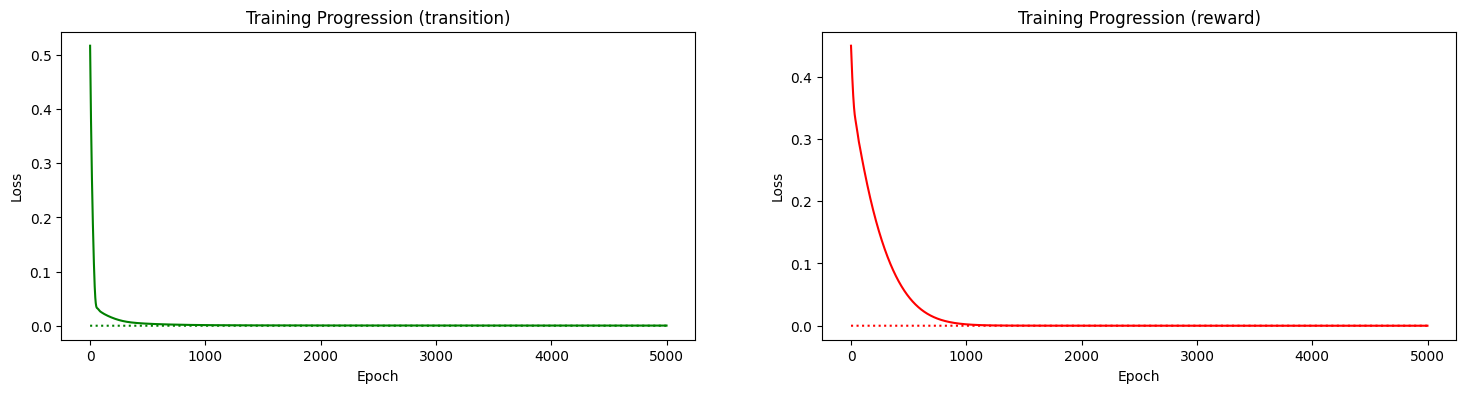

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

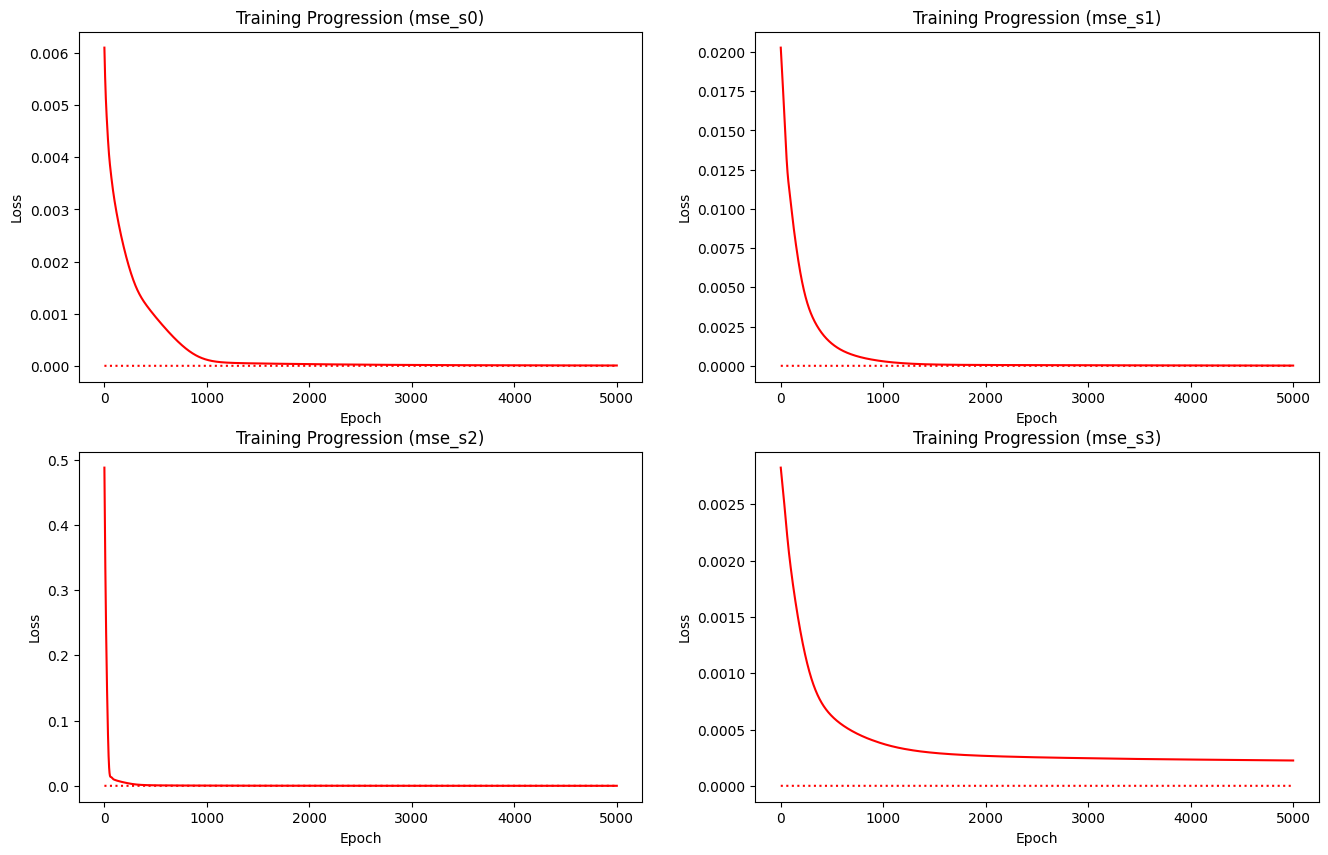

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

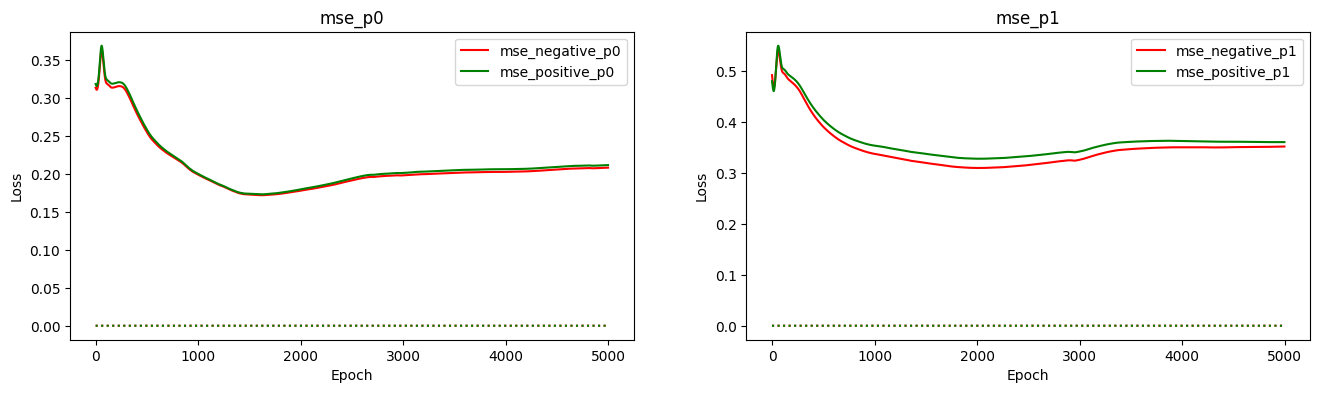

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

## Params

In [9]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_10760/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.185925,0.509421,0.152397,0.519114,-0.182793,0.269464,0.0
1,499,0.074689,0.135049,0.144953,0.443711,-0.166331,0.233095,1.0
2,499,0.244447,0.484683,0.043388,0.564132,-0.233800,0.191767,2.0
3,499,0.043388,0.564132,0.662494,0.711303,0.005538,0.445653,3.0
4,499,0.096601,0.364150,0.244447,0.484683,-0.562421,-0.054549,4.0


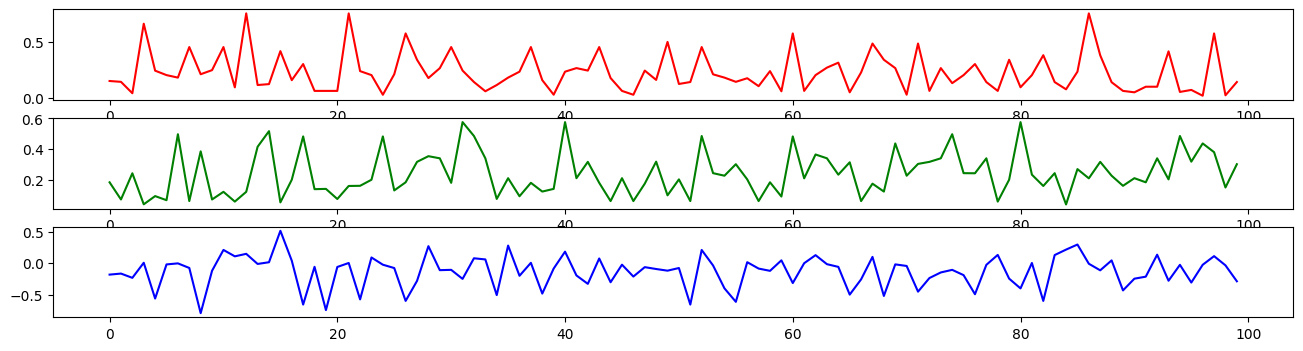

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

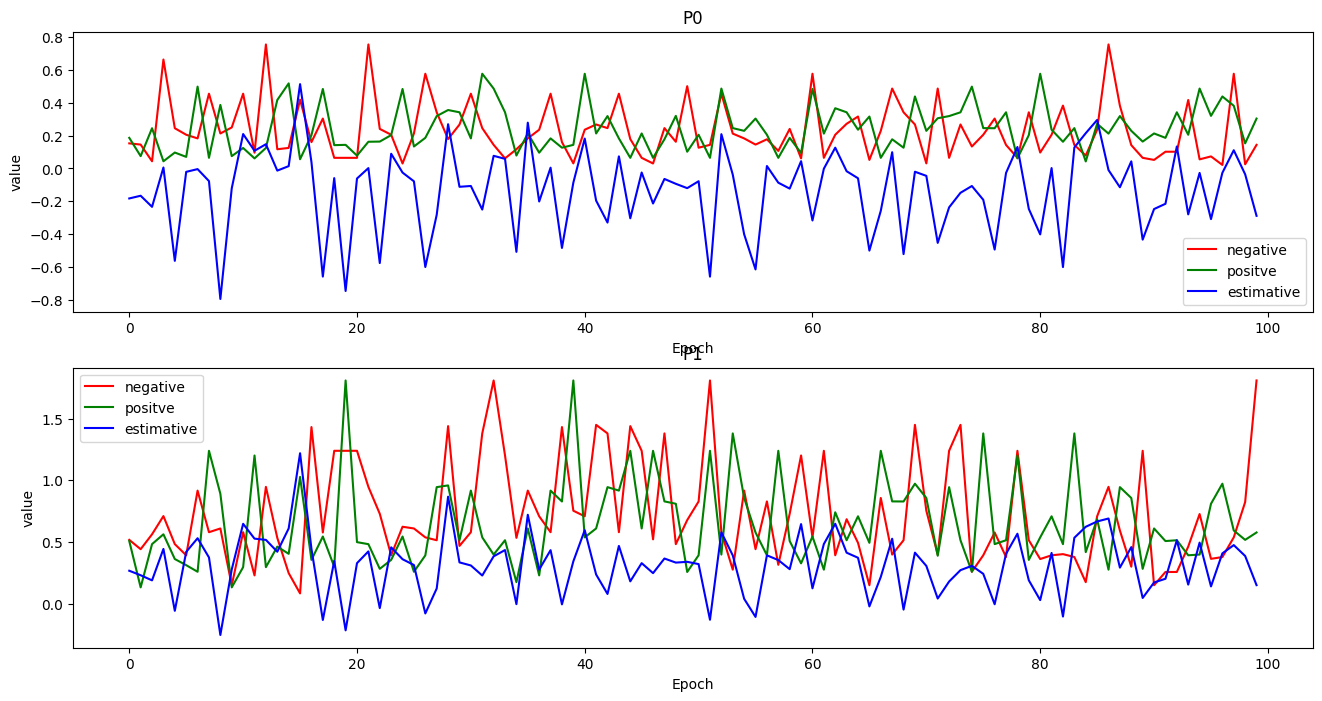

In [11]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [12]:
data.evaluate_model(model, path='../training_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.0730412080386606, 0.3656961190344961)","(0.011, 0.034, 0.014, 0.009)",0,1.0,"(0.012, -0.165, 0.014, 0.407)",0.0,1.0,"(0.009, -0.365, 0.023, 0.806)",...,0.002,0.001,0.081,0.0,0.403414,0.419411,0.501199,0.578221,0.084,0.475561
1,1,0,"(0.0730412080386606, 0.3656961190344961)","(0.012, -0.165, 0.014, 0.407)",0,1.0,"(0.009, -0.365, 0.023, 0.806)",0.0,1.0,"(0.001, -0.565, 0.039, 1.207)",...,0.006,0.000,0.067,0.0,0.403830,0.420108,0.498801,0.577380,0.074,0.475030
2,2,0,"(0.0730412080386606, 0.3656961190344961)","(0.009, -0.365, 0.023, 0.806)",0,1.0,"(0.001, -0.565, 0.039, 1.207)",0.0,1.0,"(-0.01, -0.766, 0.063, 1.616)",...,0.007,0.001,0.032,0.0,0.405495,0.420282,0.501199,0.575279,0.045,0.475564
3,3,0,"(0.0730412080386606, 0.3656961190344961)","(0.001, -0.565, 0.039, 1.207)",0,1.0,"(-0.01, -0.766, 0.063, 1.616)",1.0,1.0,"(-0.025, -0.567, 0.095, 1.25)",...,0.004,0.001,0.127,0.0,0.406328,0.419760,0.501199,0.580982,0.139,0.477067
4,4,0,"(0.0730412080386606, 0.3656961190344961)","(-0.01, -0.766, 0.063, 1.616)",1,1.0,"(-0.025, -0.567, 0.095, 1.25)",1.0,1.0,"(-0.036, -0.369, 0.12, 0.9)",...,0.006,0.000,0.082,0.0,0.403414,0.420108,0.498801,0.578281,0.088,0.475151


In [13]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([63, 73, 87]) worst_episodes=array([17, 20, 32])


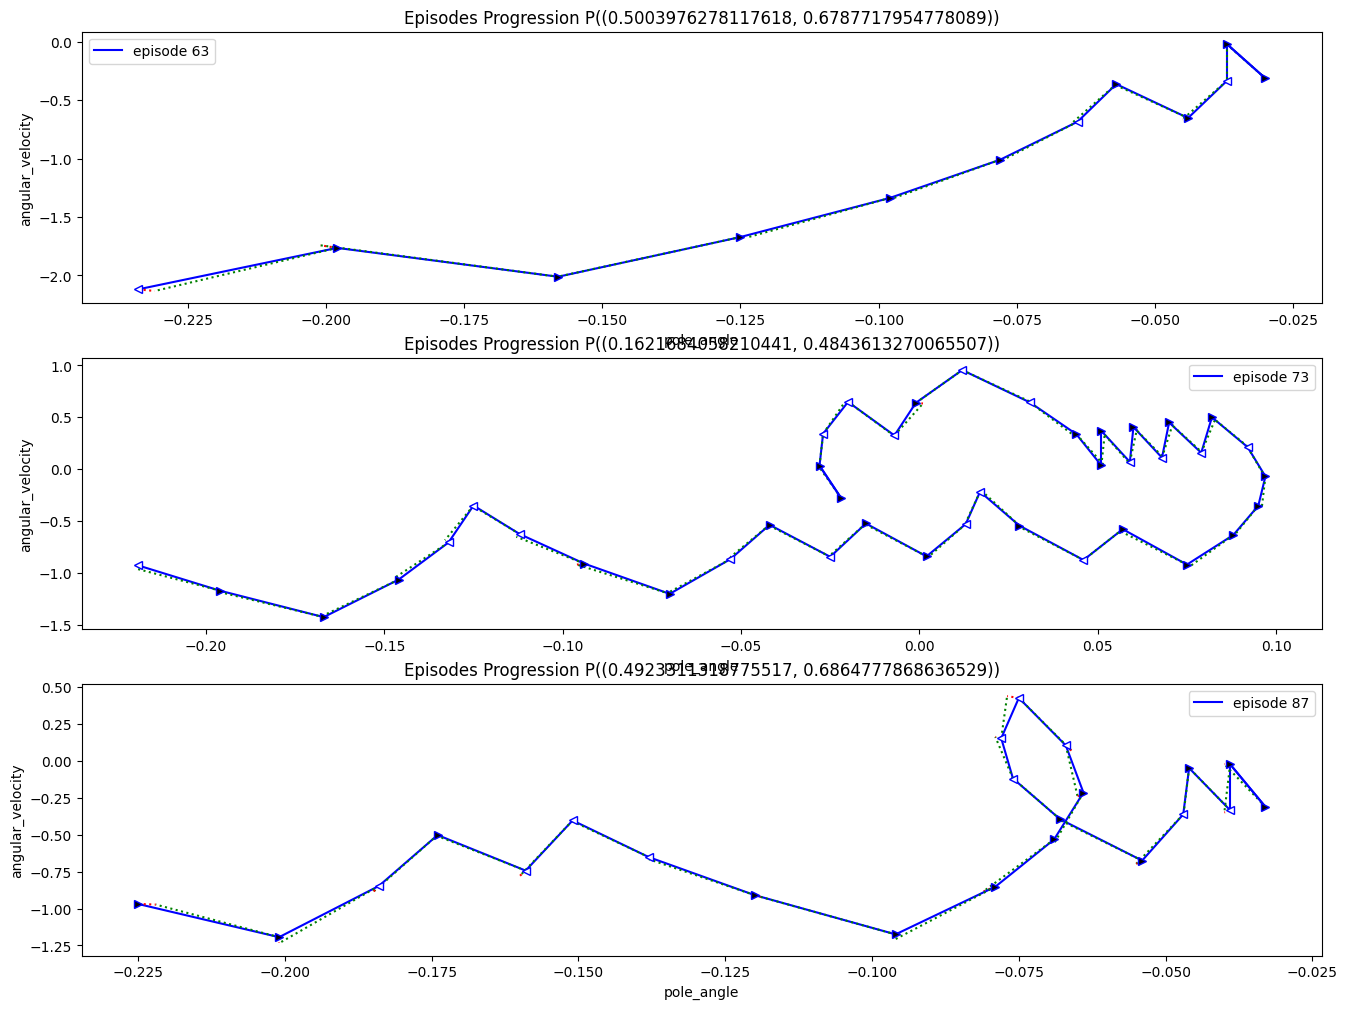

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

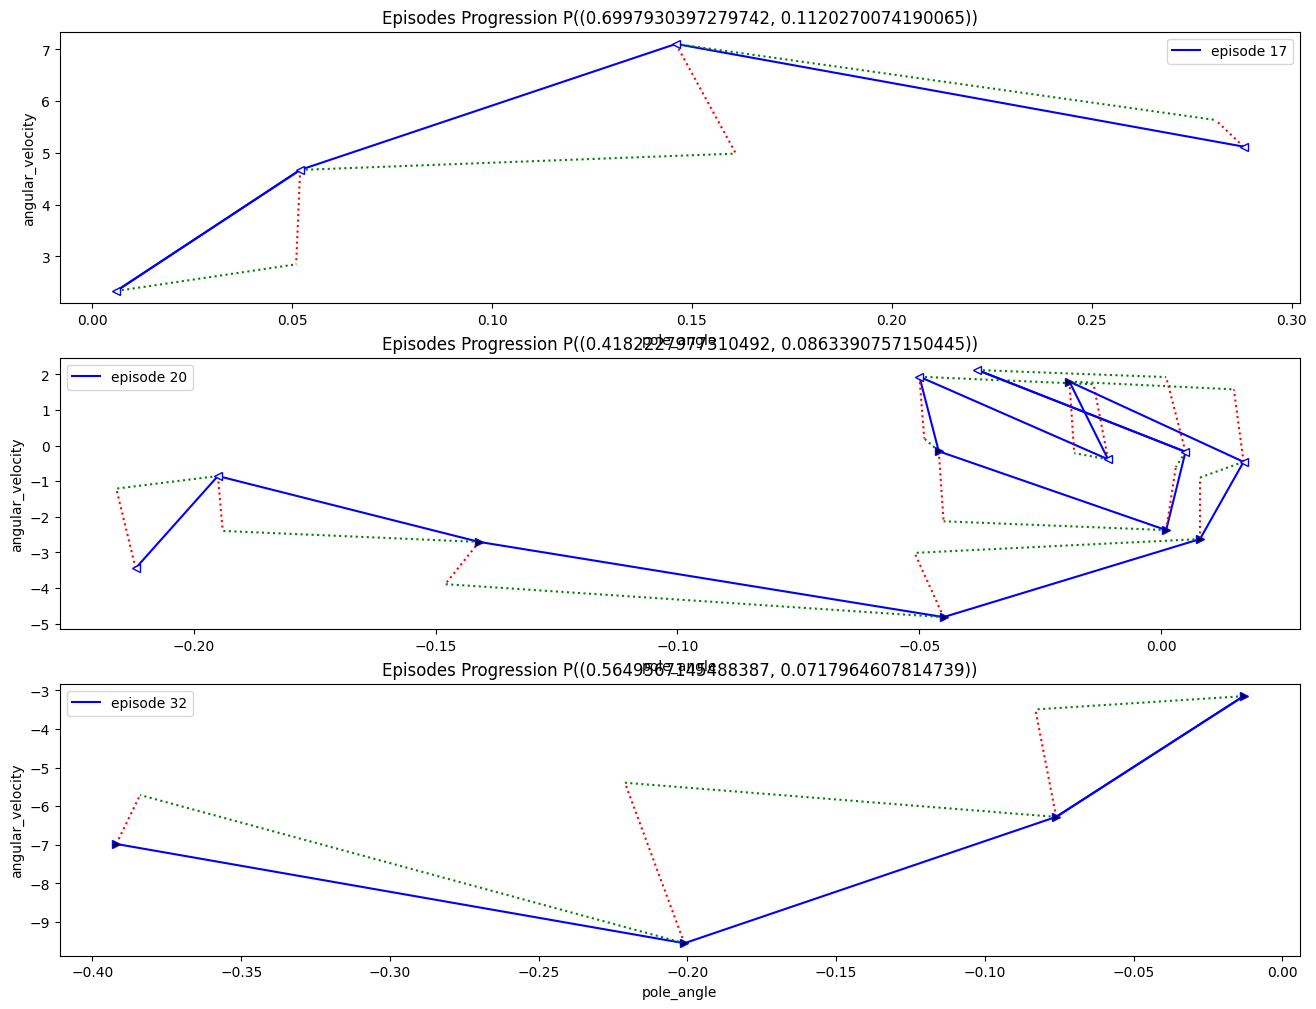

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

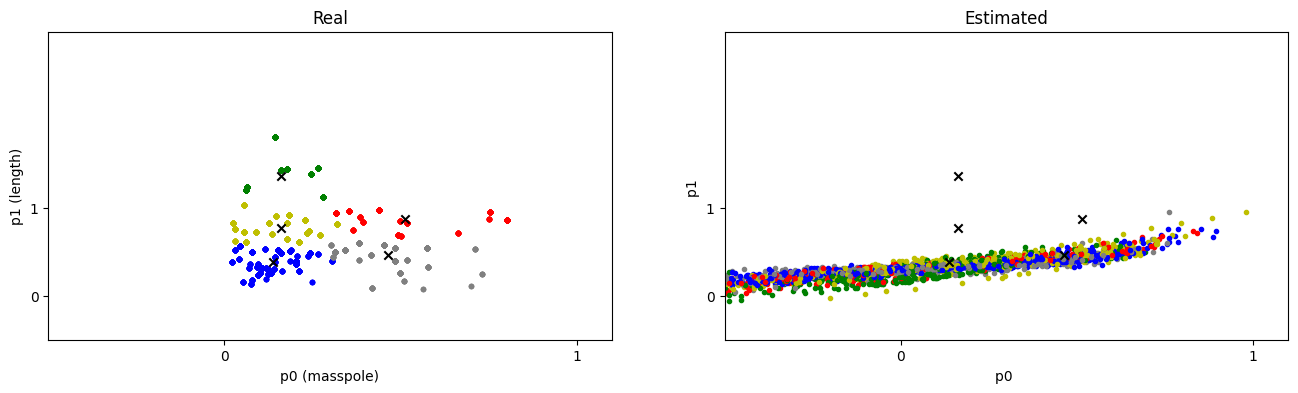

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Evaluation

In [17]:
data.evaluate_model(model, path='../testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.048,0.002,0.881,0.0,0.545935,0.537856,0.505995,0.510054,0.931,0.524960
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.053,0.002,1.048,0.0,0.553326,0.539086,0.505995,0.524343,1.110,0.530688
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.042,0.002,0.932,0.0,0.548046,0.536382,0.505995,0.514418,0.978,0.526210
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.071,0.003,0.950,0.0,0.574446,0.543510,0.508393,0.515958,1.051,0.535577
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.033,0.001,0.969,0.0,0.557550,0.534169,0.503597,0.517584,1.014,0.528225


In [18]:
results[['rse', 'rse_normalized', 
         'rse_s0', 'rse_s0_normalized',
         'rse_s1', 'rse_s1_normalized', 
         'rse_s2', 'rse_s2_normalized',
         'rse_s3', 'rse_s3_normalized']].describe()

,rse,rse_normalized,rse_s0,rse_s0_normalized,rse_s1,rse_s1_normalized,rse_s2,rse_s2_normalized,rse_s3,rse_s3_normalized
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.187060,0.508011,0.003585,0.549720,0.013310,0.529329,0.001109,0.503859,0.169056,0.449136
std,0.218208,0.005879,0.004557,0.004812,0.014871,0.003656,0.001760,0.004220,0.209270,0.017906
min,0.003000,0.502131,0.000000,0.545935,0.000000,0.526057,0.000000,0.501199,0.000000,0.434671
25%,0.074000,0.504967,0.001000,0.546990,0.005000,0.527286,0.000000,0.501199,0.060000,0.439805
50%,0.129000,0.506436,0.002000,0.548046,0.009000,0.528269,0.001000,0.503597,0.112000,0.444254
75%,0.213500,0.508617,0.005000,0.551214,0.016000,0.529990,0.001000,0.503597,0.193000,0.451185
max,2.226000,0.559652,0.068000,0.617740,0.162000,0.565880,0.024000,0.558753,2.137000,0.617524


In [19]:
import numpy as np

n = 10

df = results[['episode', 'estimated_p0', 'estimated_p1', 'p0', 'p1']].groupby("episode").mean().reset_index()
df['dist_p0'] = np.sqrt(np.pow(df['estimated_p0']-df['p0'], 2))
df['dist_p1'] = np.sqrt(np.pow(df['estimated_p1']-df['p1'], 2))
df['dist'] = df['dist_p0'] + df['dist_p1']
worst = df.loc[df.rank(ascending=False)['dist']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)


/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/pyt

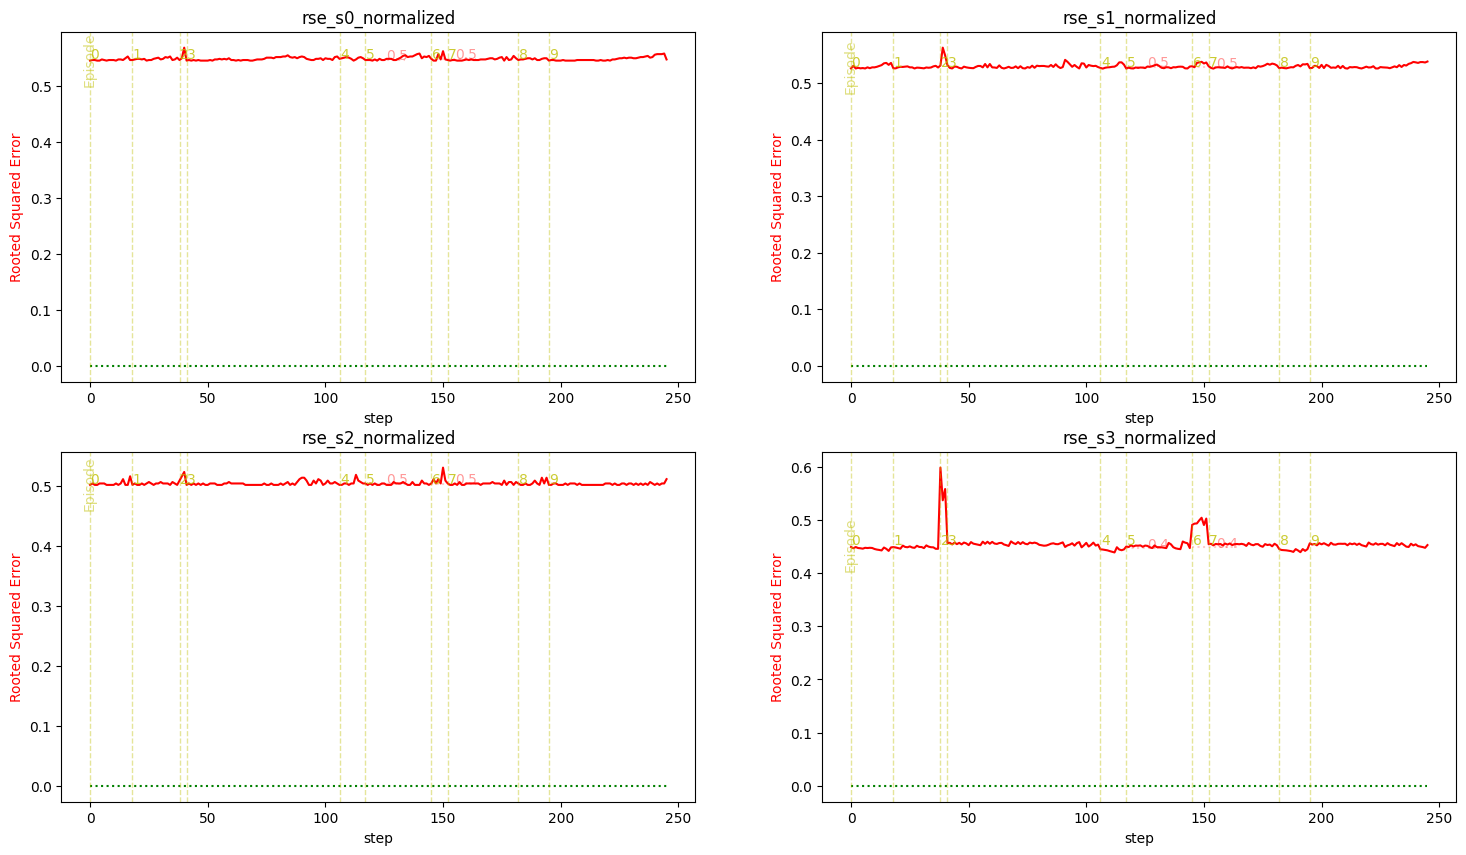

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], df, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], df, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], df, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], df, 'rse_s3_normalized')

plt.show()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


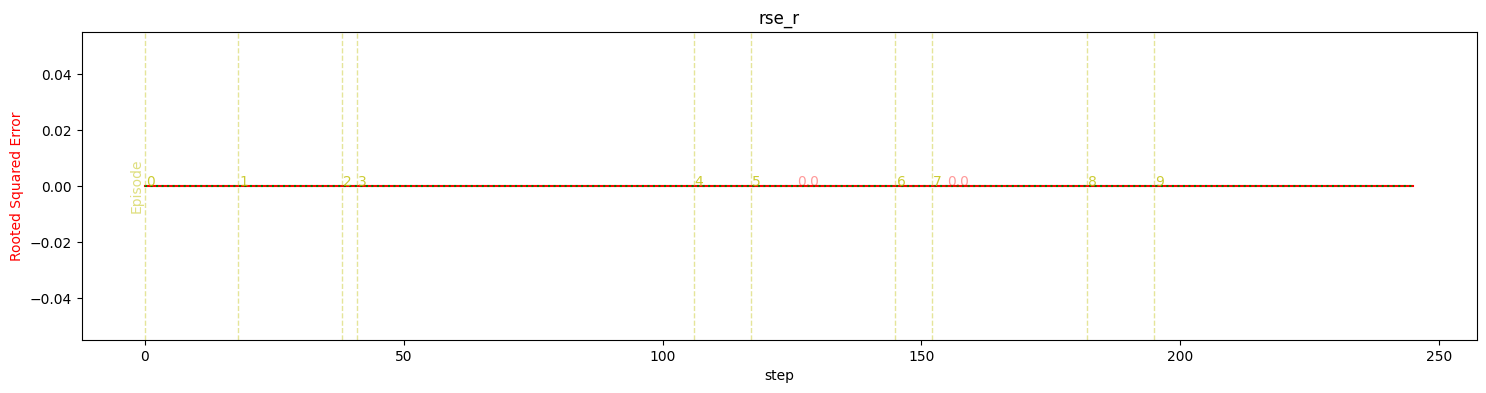

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, df, 'rse_r')
plt.show()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/pyt

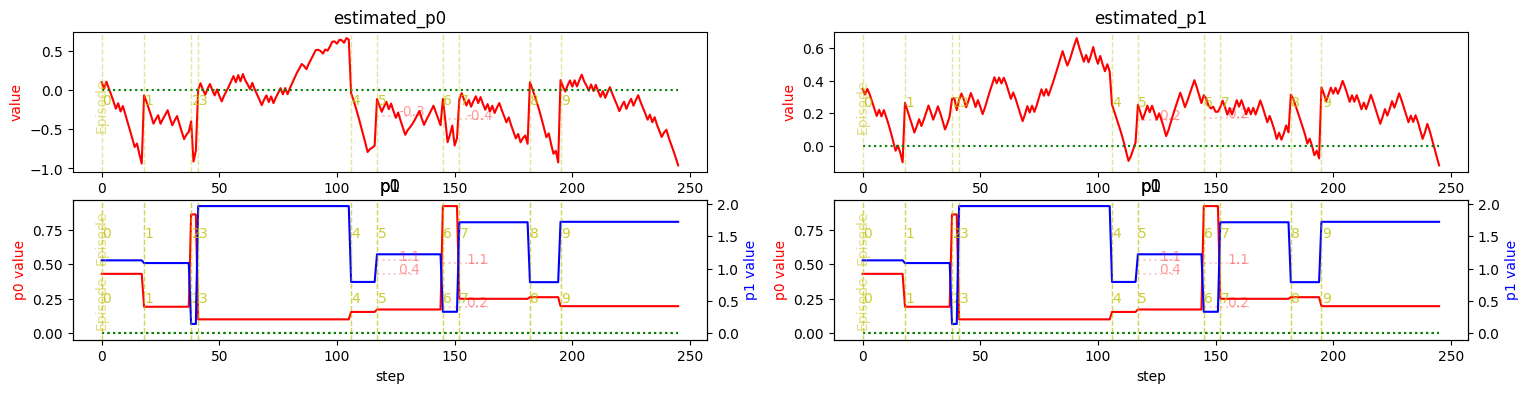

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], df, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], df, 'estimated_p1', y_label='value')

data.plot_value_through_episodes(axs[1][0], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][0].twinx(), df, 'p1', y_label='p1 value', color='b')

data.plot_value_through_episodes(axs[1][1], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][1].twinx(), df, 'p1', y_label='p1 value', color='b')

plt.show()

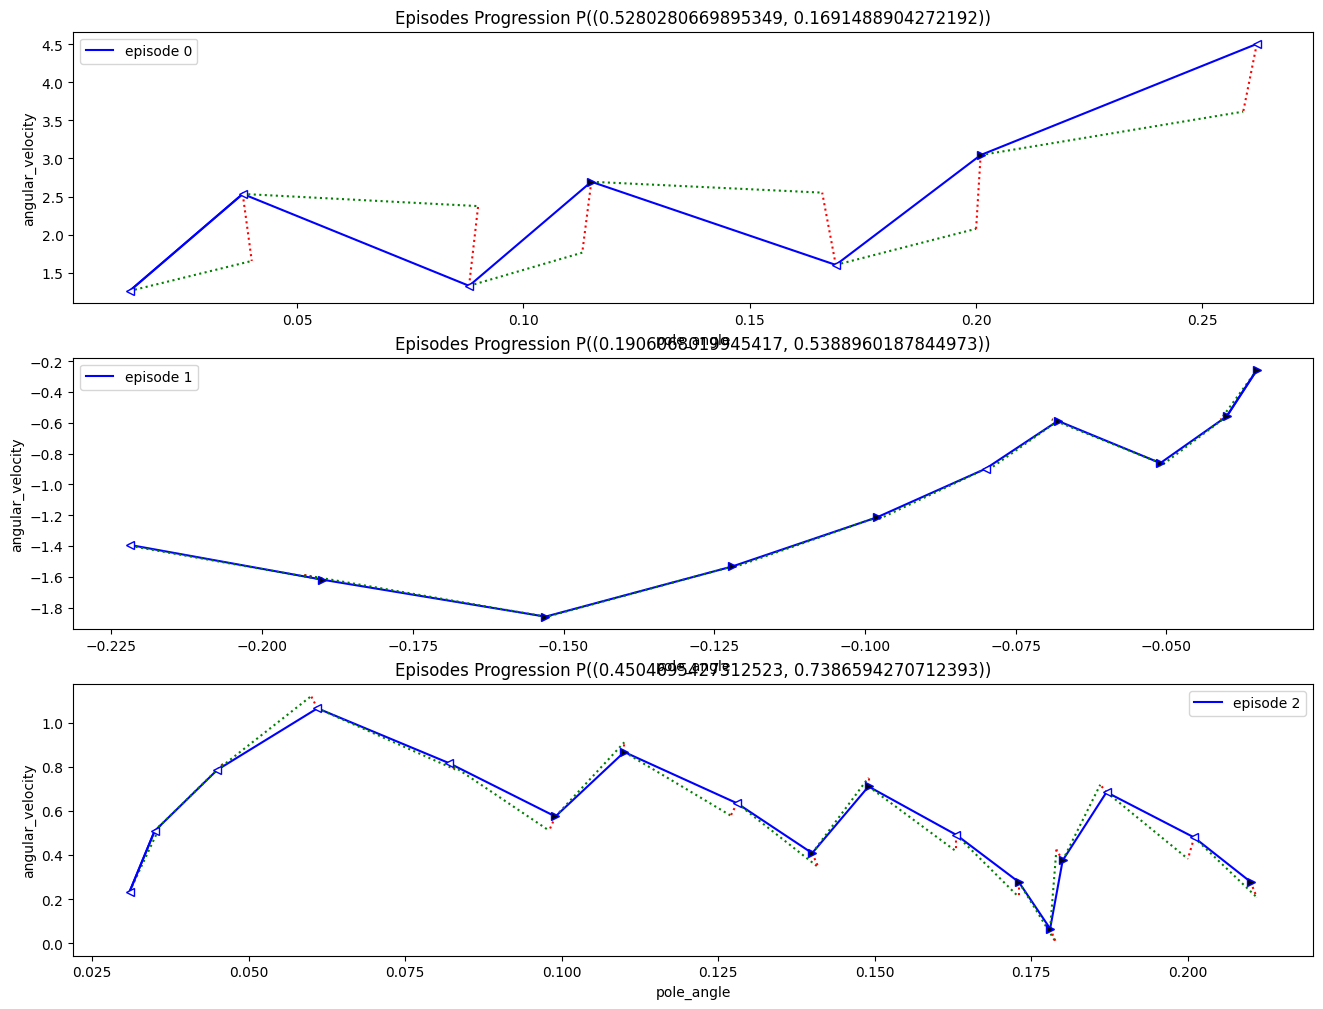

In [23]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()

## Cluster

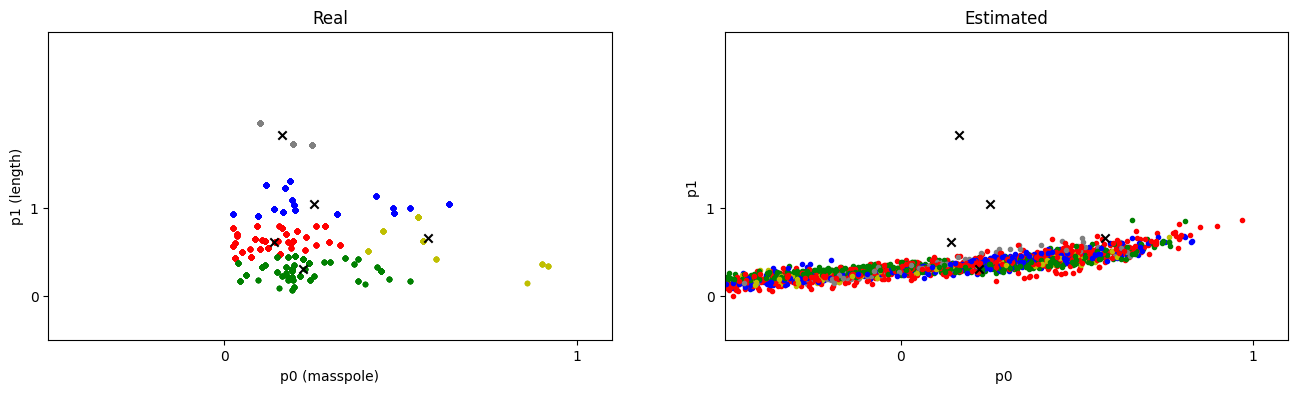

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Save

In [25]:
import pickle

exp = {
    "data": data,
    "model": model 
}

nome_do_arquivo = 'regular_normilized.pkl'
with open(nome_do_arquivo, 'wb') as arquivo:
    pickle.dump(exp, arquivo)